Isaac Noe

9/27/2026

Code lab 5 — Central Forces, Gravity & Orbits

In [80]:
import numpy as np
import matplotlib.pyplot as plt
G = 1
M = 1

Part A — A Single Orbit with Velocity Verlet (25 points)

In [81]:
# Part 1
# Implement verlet_step
def verlet_step(r, v, a, dt, accel_func):
    """One Velocity Verlet step. accel_func(r) returns acceleration at position r."""
    r_new = r + v * dt + 0.5 * a * dt**2
    a_new = accel_func(r_new)
    v_new = v + 0.5 * (a + a_new) * dt
    return r_new, v_new, a_new

In [82]:
# Part 2
# Acceleration function
def accel_func(r):
    """Acceleration due to gravity at position r."""
    r_mag = np.linalg.norm(r)
    return -G * M * r / r_mag**3

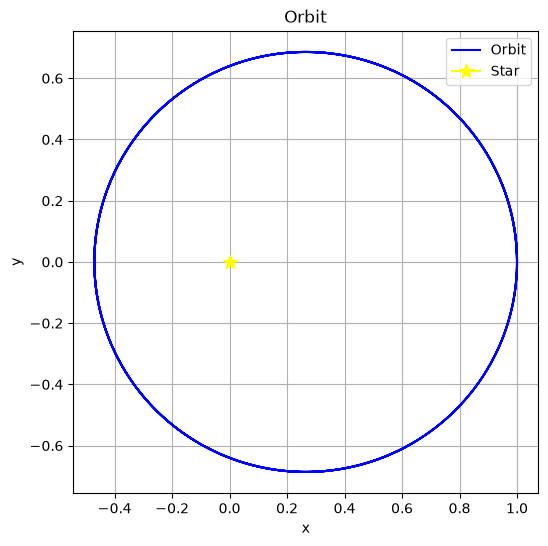

In [83]:
# Part 3
# Run a bound orbit

# Initial conditions for a bound elliptical orbit
r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])   # less than circular speed (=1.0) -> ellipse
a = accel_func(r)
steps = 15000

dt = 0.001
rs = [r.copy()]
vs = [v.copy()]
for _ in range(steps):
    r, v, a = verlet_step(r, v, a, dt, accel_func)
    rs.append(r.copy())
    vs.append(v.copy())
rs = np.array(rs)
vs = np.array(vs)

# Plot the Orbit Around the Star
plt.figure(figsize=(6, 6))
plt.plot(rs[:, 0], rs[:, 1], label='Orbit', color='blue')
plt.plot(0, 0, marker='*', label='Star' ,color='yellow', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Orbit')
plt.legend()
plt.grid()
plt.show()


This graph shows the orbit of a body around a star.

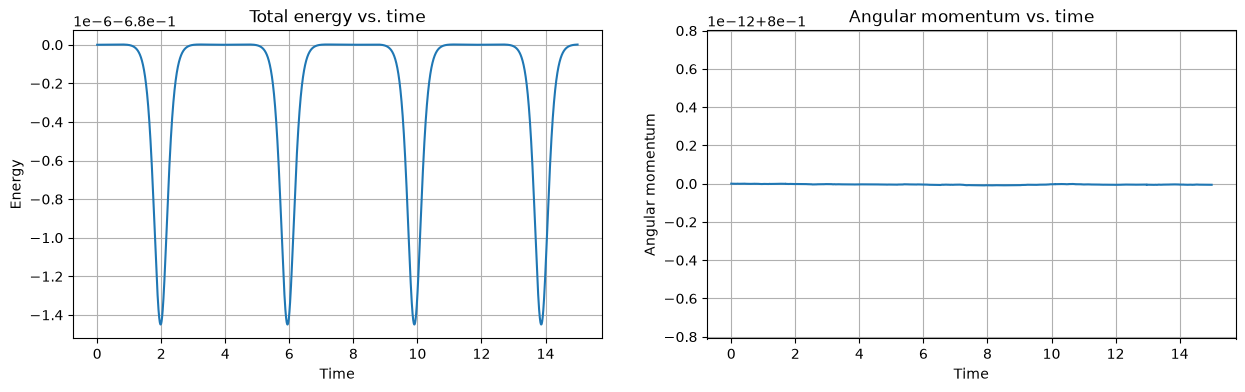

In [84]:
# Part 4
# Defining angular momentum and total energy
def energy(r, v, G=1.0, M=1.0, m=1.0):
    ke = 0.5 * m * np.dot(v, v)
    pe = -G * M * m / np.linalg.norm(r)
    return ke + pe

def ang_momentum(r, v, m=1.0):
    # 2D cross product r x v is a scalar
    return m * (r[0] * v[1] - r[1] * v[0])

#Plotting energy and angular momentum vs time
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

time = np.arange(0, dt * len(rs), dt)
energy = [energy(r, v) for r, v in zip(rs, vs)]
ang_momentum = [ang_momentum(r, v) for r, v in zip(rs, vs)]

axes[0].plot(time, energy)
axes[0].set(title="Total energy vs. time", xlabel="Time", ylabel="Energy")
axes[0].grid()

axes[1].plot(time, ang_momentum)
axes[1].set(title="Angular momentum vs. time", xlabel="Time", ylabel="Angular momentum")
axes[1].grid()

plt.show()

This graphs show the total energy and angular momentum vs time.

Part 5

Is your starting point periapsis or apoapsis?  How do you know from v0 = 0.8 compared to the circular speed of 1.0?

The starting point is apoapsis because the speed is slowest at the apoapsis.

Part B — The Integrator Showdown (35 points)

In [85]:
# Part 1
# Defining simulate function
def simulate(method, r0, v0, dt, steps):
    "Simulate an orbit using Euler, Euler-Cromer, or Velocity Verlet."
    r = np.array(r0)
    v = np.array(v0)

    positions = [r.copy()]
    velocities = [v.copy()]

    if method == "verlet":
        a = accel_func(r)

    for _ in range(steps):
        if method == "euler":
            r_new = r + v * dt
            v_new = v + accel_func(r) * dt

        elif method == "euler-cromer":
            v_new = v + accel_func(r) * dt
            r_new = r + v_new * dt

        elif method == "verlet":
            r_new, v_new, a = verlet_step(r, v, a, dt, accel_func)

        r, v = r_new, v_new
        positions.append(r.copy())
        velocities.append(v.copy())

    return np.array(positions), np.array(velocities)

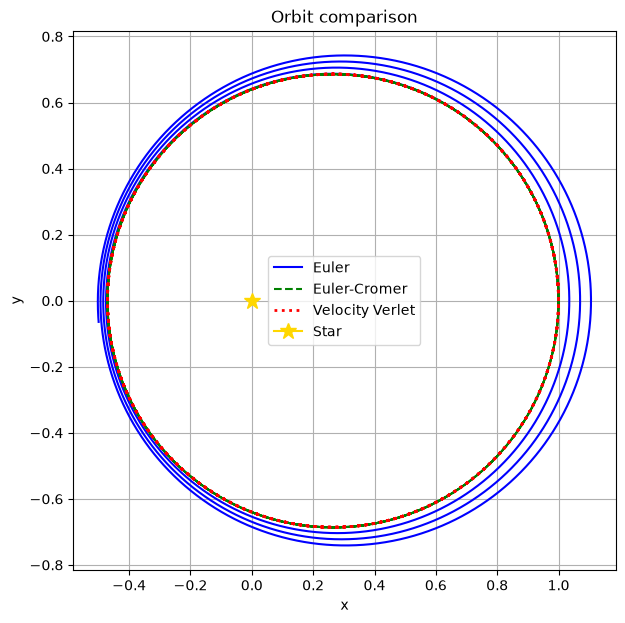

In [86]:
# Part 2
# Run all three and overlay the trajectories

r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])
dt = 0.001
steps = 15000

euler_r, euler_v = simulate("euler", r, v, dt, steps)
euler_cromer_r, euler_cromer_v = simulate("euler-cromer", r, v, dt, steps)
verlet_r, verlet_v = simulate("verlet", r, v, dt, steps)

# Overlay the trajectories
plt.figure(figsize=(7, 7))

plt.plot(euler_r[:, 0], euler_r[:, 1], label="Euler", color="blue")
plt.plot(euler_cromer_r[:, 0], euler_cromer_r[:, 1], label="Euler-Cromer", color="green", linestyle="--", linewidth=1.5)
plt.plot(verlet_r[:, 0], verlet_r[:, 1], label="Velocity Verlet", color="red", linestyle=":", linewidth=2)

plt.plot(0, 0, marker="*", color="gold", markersize=12, label="Star")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Orbit comparison")
plt.grid()
plt.legend()
plt.show()

This graph shows three orbits with identical conditions but using diffrent methods (Euler, Euler-Cromer, and Verlet).

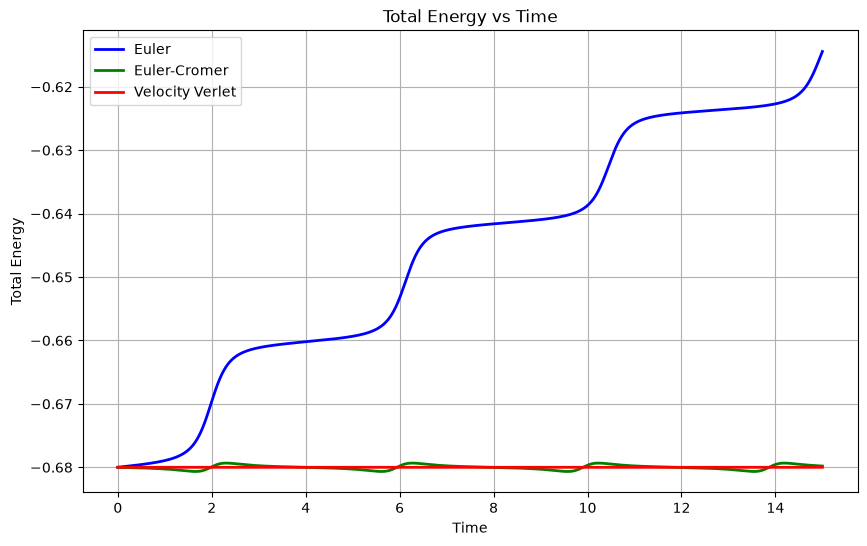

In [87]:
# Part 3
# Plotting energy vs time for each method
time = np.arange(0, dt * (steps + 1), dt)

# Calculate total energy for each method
energy_e = (0.5 * np.sum(euler_v**2, axis=1) - G * M / np.linalg.norm(euler_r, axis=1)).tolist()

energy_ec = (0.5 * np.sum(euler_cromer_v**2, axis=1) - G * M / np.linalg.norm(euler_cromer_r, axis=1)).tolist()

energy_v = (0.5 * np.sum(verlet_v**2, axis=1) - G * M / np.linalg.norm(verlet_r, axis=1)).tolist()

# Plotting the total energy vs time for each method
plt.figure(figsize=(10, 6))
plt.plot(time, energy_e, label="Euler", color="blue", linewidth=2)
plt.plot(time, energy_ec, label="Euler-Cromer", color="green", linewidth=2)
plt.plot(time, energy_v, label="Velocity Verlet", color="red", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Total Energy")
plt.title("Total Energy vs Time")
plt.grid()
plt.legend()
plt.show()


This graph show the total energy of Euler, Euler-Cromer, and Verlet as a function of time. 

In [88]:
# Maximum fractional energy error for each integration method
E0 = -0.68

fractional_error_euler = np.max(np.abs((np.asarray(energy_e) - E0) / E0))
fractional_error_euler_cromer = np.max(np.abs((np.asarray(energy_ec) - E0) / E0))
fractional_error_verlet = np.max(np.abs((np.asarray(energy_v) - E0) / E0))

In [89]:
# Print the maximum change and fractional error in energy for each method
for name, values in [("Euler", energy_e), ("Euler-Cromer", energy_ec), ("Velocity Verlet", energy_v),]:
    delta_E = np.max(np.abs(np.asarray(values) - E0))
    fractional_delta = delta_E / abs(E0)
    print(f"{name:15s}: ΔE = {delta_E:.6e},  |ΔE/E₀| = {fractional_delta:.6e}")

Euler          : ΔE = 6.556167e-02,  |ΔE/E₀| = 9.641422e-02
Euler-Cromer   : ΔE = 6.639154e-04,  |ΔE/E₀| = 9.763462e-04
Velocity Verlet: ΔE = 1.449667e-06,  |ΔE/E₀| = 2.131864e-06


Part 4
Summary Table

|| Euler | Euler-Cromer | Verlet |
|--------| -------- | -------- | -------- |
| E₀ |-0.68|-0.68|-0.68|
| ΔE | 6.556167e-02 | 6.639154e-04 | 1.449667e-06 |
| ΔE/E₀ |9.641422e-02|9.763462e-04|2.131864e-06|


Part 5

Write the analysis: Why does Euler gain energy and spiral outward?  Why is Verlet stable even though it's only second-order accurate?  Connect this to the word "symplectic."

Euler gains energy because its update only uses the acceleration and velocity from the beginning
of each time step. Which causes its error to compound and spiral outward. Verlet is stable because it is symplectic wich allows it to preserve phase-space and its energy error remains close to the true value. So the orbits stays bounded.

Part C — Verify Kepler's Three Laws (40 points)

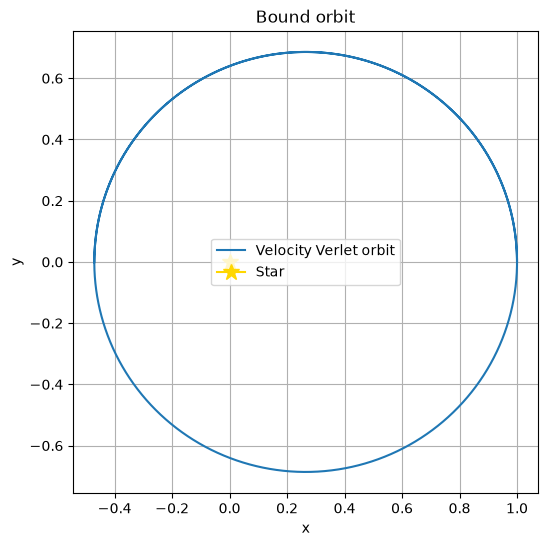

Estimated semi-major axis: 0.735295


In [90]:
# Part 1
# First law (ellipse)
dt = 0.001
r0 = np.array([1.0, 0.0])

v0 = np.array([0.0, 0.8])
a_theory = 1 / (2 / np.linalg.norm(r0) - np.dot(v0, v0) / G * M)
period = 2 * np.pi * np.sqrt(a_theory**3 / G * M)

r, v = simulate("verlet", r0, v0, dt, int(np.ceil(1.5 * period / dt)))
radius = np.linalg.norm(r, axis=1)
a = (radius.min() + radius.max()) / 2

plt.figure(figsize=(6, 6))
plt.plot(r[:, 0], r[:, 1], label="Velocity Verlet orbit")
plt.plot(0, 0, marker="*", color="gold", markersize=12, label="Star")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bound orbit")
plt.grid()
plt.legend()
plt.show()

print(f"Estimated semi-major axis: {a:.6f}")

This graph shows the orbit using verlet is a closed ellipse.

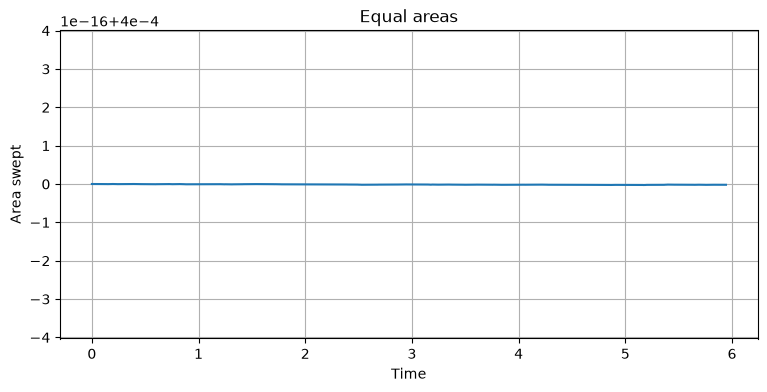

In [ ]:
# Part 2
# Second law (equal areas)
area_swept = 0.5 * np.abs(r[:, 0] * v[:, 1] - r[:, 1] * v[:, 0]) * dt
time = np.arange(len(area_swept)) * dt

plt.figure(figsize=(9, 4))
plt.plot(time, area_swept)
plt.xlabel("Time")
plt.ylabel("Area swept")
plt.title("Equal areas")
plt.grid()
plt.show()

This graph shows that the area swept remanins constant as a function of time.

Equal area swept over time step is equivalent to angular-momentum conservation because they are proportional to each other.

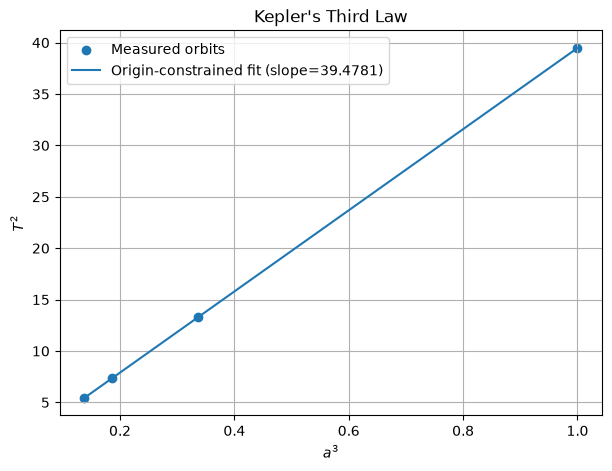

Measured slope: 39.478116
Expected slope 4π²/(GM): 39.478418
Percent difference: 0.000764%


In [94]:
# Part 3
# Third law
v0_values = [0.25, 0.50, 0.75, 1.00]
measured_a = []
measured_T = []

for speed in v0_values:
    v0 = np.array([0.0, speed])
    a_theory = 1 / (2 / np.linalg.norm(r0) - np.dot(v0, v0) / (G * M))
    T_estimate = 2 * np.pi * np.sqrt(a_theory**3 / (G * M))
    n_steps = int(np.ceil(2.2 * T_estimate / dt))

    r_orbit, v_orbit = simulate("verlet", r0, v0, dt, n_steps)
    radius = np.linalg.norm(r_orbit, axis=1)
    a_estimate = (radius.min() + radius.max()) / 2

    radial_motion = np.sum(r_orbit * v_orbit, axis=1)
    crossings = np.flatnonzero((radial_motion[:-1] < 0) & (radial_motion[1:] >= 0))
    event_times = []
    for i in crossings:
        fraction = -radial_motion[i] / (radial_motion[i + 1] - radial_motion[i])
        event_times.append((i + fraction) * dt)

    T_measured = np.mean(np.diff(event_times))
    measured_a.append(a_estimate)
    measured_T.append(T_measured)

a_cubed = np.asarray(measured_a) ** 3
T_squared = np.asarray(measured_T) ** 2

slope = np.dot(a_cubed, T_squared) / np.dot(a_cubed, a_cubed)
expected_slope = 4 * np.pi**2 / (G * M)
slope_error = 100 * abs(slope - expected_slope) / expected_slope

plt.figure(figsize=(7, 5))
plt.scatter(a_cubed, T_squared, label="Measured orbits")
plt.plot(a_cubed, slope * a_cubed, label=f"Origin-constrained fit (slope={slope:.4f})")
plt.xlabel("$a^3$")
plt.ylabel("$T^2$")
plt.title("Kepler's Third Law")
plt.grid()
plt.legend()
plt.show()

print(f"Measured slope: {slope:.6f}")
print(f"Expected slope 4π²/(GM): {expected_slope:.6f}")
print(f"Percent difference: {slope_error:.6f}%")

This graph shows that the period squared vs the semi-major axis to the fifth is a straight line through the origin.

Part 4

Analysis:  How well do your measured slopes match theory? What's your main source of error, step size, period-measurement resolution, or semi-major-axis estimation?

The measured slopes match theory very well. My main source of error is most likely the semi-major-axis estimation.